# Model Evaluation — Clean Temporal Prithvi

This notebook evaluates the model trained by
`Training_and_Segmentation_Clean_New.ipynb` using the clean validation
TFRecord. It is based on `3. model_evaluation.ipynb`, but uses the clean
v2 TFRecord schema, explicit temporal masks, and the matching
`MaskedPrithviEncoder` architecture.

One inference pass reports metrics for all validation records, cloudy
records, non-cloudy records, and each exact sequence version. Manual
timestep ablations use the same one-based convention as
`visualize_prediction`.


## Experiment controls

The fixed sequence is `[t1 history, t2 history, t3 target, t4 future]`.
Set `MASKED_TIMESTEPS` to the positions to remove before inference:

- `[]`: use every source-valid frame.
- `[1, 2, 4]`: target only.
- `[3]`: context only; mask the target image.
- `[3, 4]`: history only.
- `[1, 2, 3]`: future only.

The mask is applied to the image, temporal coordinates, and temporal mask.
Records that have no active frame after masking are skipped and counted so
that masking comparisons cannot silently include all-zero inputs.


## Environment

Run the installation cell only when the environment needs it.


In [ ]:
%pip install "numpy<2" "opencv-python==4.11.0.86" "opencv-python-headless==4.11.0.86" "albumentations==1.4.6" "terratorch==1.0" "torchgeo==0.6.2" "rasterio==1.4.4"


In [1]:
import importlib.util
import os
import random
import struct
import time
from itertools import islice
from pathlib import Path

# Rasterio's wheel contains the PROJ database matching its runtime.
_rasterio_spec = importlib.util.find_spec("rasterio")
if _rasterio_spec is not None:
    _proj_data = Path(_rasterio_spec.origin).parent / "proj_data"
    if _proj_data.exists():
        os.environ["PROJ_DATA"] = str(_proj_data)
        os.environ["PROJ_LIB"] = str(_proj_data)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

# TensorFlow is used only to decode TFRecords; reserve the GPU for PyTorch.
try:
    tf.config.set_visible_devices([], "GPU")
    print("TensorFlow GPU disabled.")
except RuntimeError as error:
    print(
        "TensorFlow was already initialized. Restart the kernel and run "
        "this cell before any TensorFlow work if it reserved GPU memory."
    )
    print(error)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

VAL_TFRECORD = Path(
    r"D:\Data\ssm_temporal\ssm_footprint_val_clean.tfrecord"
)
FINETUNED_MODEL_PATH = Path(
    "models/prithvi_state_dict_clean_new.pt"
)

TIMESTEPS = 4
TARGET_INDEX = 2  # zero-based internally: t3 is the segmentation target
IMAGE_SIZE = 224
IN_CHANNELS = 6
NUM_CLASSES = 3
VAL_BATCH_SIZE = 4
NUM_WORKERS = 0

# Class labels can be renamed here without changing metric calculations.
CLASS_NAMES = {
    0: "background",
    1: "foreground_1",
    2: "foreground_2",
}

# One-based manual mask, matching visualize_prediction.
MASKED_TIMESTEPS = []

CLOUD_VERSIONS = frozenset(
    {"harmonized_cloudy", "sr_harmonized_cloudy"}
)
NO_CLOUD_VERSIONS = frozenset(
    {"harmonized", "sr_harmonized"}
)
VERSION_GROUPS = {
    "cloud": CLOUD_VERSIONS,
    "no_cloud": NO_CLOUD_VERSIONS,
}

# A single run evaluates MASKED_TIMESTEPS. A sweep rereads the 25 GB
# validation TFRecord once per scenario, so it is disabled by default.
RUN_SINGLE_EVALUATION = True
RUN_MASKING_SWEEP = False
INCLUDE_VERSION_ROWS = True
EMPTY_SAMPLE_POLICY = "skip"  # "skip" or "error"
MAX_BATCHES = None  # Use 1 or 2 for a quick pipeline smoke test.
SAVE_RESULTS = False
RESULTS_DIRECTORY = Path("outputs/model_evaluation_clean_new")

MASKING_SCENARIOS = {
    "all_frames": [],
    "target_only": [1, 2, 4],
    "context_only": [3],
    "history_and_target": [4],
    "target_and_future": [1, 2],
    "history_only": [3, 4],
    "future_only": [1, 2, 3],
}

assert TIMESTEPS == 4
assert TARGET_INDEX == 2
assert CLOUD_VERSIONS.isdisjoint(NO_CLOUD_VERSIONS)
assert set().union(*VERSION_GROUPS.values()) == (
    CLOUD_VERSIONS | NO_CLOUD_VERSIONS
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Validation TFRecord:", VAL_TFRECORD)
print("Fine-tuned checkpoint:", FINETUNED_MODEL_PATH)
print("Manual timestep mask:", MASKED_TIMESTEPS or "none")

if not VAL_TFRECORD.exists():
    raise FileNotFoundError(f"Validation TFRecord not found: {VAL_TFRECORD}")
if not FINETUNED_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Fine-tuned checkpoint not found: {FINETUNED_MODEL_PATH}"
    )


c:\Users\emmanuelasare\AppData\Local\anaconda3\envs\ml-env2\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow GPU disabled.
Device: cuda
Validation TFRecord: D:\Data\ssm_temporal\ssm_footprint_val_clean.tfrecord
Fine-tuned checkpoint: models\prithvi_state_dict_clean_new.pt
Manual timestep mask: none


## Clean TFRecord dataset

This is the same v2 reader and deterministic validation collation used by
`Training_and_Segmentation_Clean_New.ipynb`. No augmentation or random
context dropout is applied during evaluation.


In [2]:
def _center_pad_hw(array, target_hw):
    target_h, target_w = target_hw
    h, w = array.shape[:2]
    pad_h = max(target_h - h, 0)
    pad_w = max(target_w - w, 0)
    pad_top = pad_h // 2
    pad_left = pad_w // 2
    padding = [
        (pad_top, pad_h - pad_top),
        (pad_left, pad_w - pad_left),
    ]
    padding.extend([(0, 0)] * (array.ndim - 2))
    return np.pad(array, padding, mode="constant")


def _center_pad_cthw(image, target_hw):
    channels, timesteps, h, w = image.shape
    image_hwc = image.transpose(2, 3, 0, 1).reshape(
        h, w, channels * timesteps
    )
    image_hwc = _center_pad_hw(image_hwc, target_hw)
    padded_h, padded_w, _ = image_hwc.shape
    return image_hwc.transpose(2, 0, 1).reshape(
        channels, timesteps, padded_h, padded_w
    )


def _decode_text(value):
    return value.numpy().decode("utf-8")


class MineFootprintTFRecordDataset(Dataset):
    MEAN = np.array(
        [1087.0, 1342.0, 1433.0, 2734.0, 1958.0, 1363.0],
        dtype=np.float32,
    )
    STD = np.array(
        [2248.0, 2179.0, 2178.0, 1850.0, 1242.0, 1049.0],
        dtype=np.float32,
    )

    FEATURE_DESCRIPTION = {
        "image_raw": tf.io.FixedLenFeature([], tf.string),
        "mask_raw": tf.io.FixedLenFeature([], tf.string),
        "height": tf.io.FixedLenFeature([], tf.int64),
        "width": tf.io.FixedLenFeature([], tf.int64),
        "channels": tf.io.FixedLenFeature([], tf.int64),
        "timesteps": tf.io.FixedLenFeature([], tf.int64),
        "temporal_coords": tf.io.FixedLenFeature(
            [TIMESTEPS * 2], tf.float32
        ),
        "temporal_mask": tf.io.FixedLenFeature(
            [TIMESTEPS], tf.float32
        ),
        "location_coords": tf.io.FixedLenFeature([2], tf.float32),
        "target_index": tf.io.FixedLenFeature([], tf.int64),
        "target_year": tf.io.FixedLenFeature([], tf.int64),
        "sequence_version": tf.io.FixedLenFeature([], tf.string),
        "background_only": tf.io.FixedLenFeature([], tf.int64),
        "foreground_pixel_count": tf.io.FixedLenFeature([], tf.int64),
        "valid_frame_count": tf.io.FixedLenFeature([], tf.int64),
        "frame_years": tf.io.FixedLenFeature([TIMESTEPS], tf.int64),
        "target_group": tf.io.FixedLenFeature([], tf.string),
        "patch_id": tf.io.FixedLenFeature([], tf.string),
        "patch_row": tf.io.FixedLenFeature([], tf.int64),
        "patch_col": tf.io.FixedLenFeature([], tf.int64),
        "spatial_block": tf.io.FixedLenFeature([], tf.string),
        "split": tf.io.FixedLenFeature([], tf.string),
        "schema_version": tf.io.FixedLenFeature([], tf.string),
    }

    def __init__(
        self,
        tfrecord_path,
        transform=None,
        pad_to=(224, 224),
        expected_split=None,
    ):
        self.tfrecord_path = Path(tfrecord_path)
        if not self.tfrecord_path.exists():
            raise FileNotFoundError(
                f"TFRecord not found: {self.tfrecord_path}. "
                "Update the path in the configuration cell."
            )
        self.transform = transform
        self.pad_to = pad_to
        self.expected_split = expected_split
        self._offsets = self._scan_index()
        self._file = self.tfrecord_path.open("rb")

    def _scan_index(self):
        offsets = []
        size = self.tfrecord_path.stat().st_size
        position = 0
        with self.tfrecord_path.open("rb") as file:
            while position < size:
                file.seek(position)
                header = file.read(12)
                if len(header) != 12:
                    raise RuntimeError(
                        f"Incomplete TFRecord header at byte {position:,}"
                    )
                record_length = struct.unpack("<Q", header[:8])[0]
                offsets.append(position)
                position += 12 + record_length + 4
                if position > size:
                    raise RuntimeError(
                        f"Record at byte {offsets[-1]:,} exceeds file size"
                    )
        if position != size:
            raise RuntimeError(
                f"TFRecord ended at {position:,}; file has {size:,} bytes"
            )
        return offsets

    def _read_record(self, offset):
        self._file.seek(offset)
        header = self._file.read(12)
        if len(header) != 12:
            raise RuntimeError(f"Incomplete TFRecord header at {offset:,}")
        record_length = struct.unpack("<Q", header[:8])[0]
        data = self._file.read(record_length)
        if len(data) != record_length:
            raise RuntimeError(f"Incomplete TFRecord payload at {offset:,}")
        self._file.read(4)
        return data

    def __len__(self):
        return len(self._offsets)

    def _normalize_valid_frames(self, image, temporal_mask):
        channels = image.shape[0]
        valid = temporal_mask.astype(bool)
        normalized = np.zeros_like(image, dtype=np.float32)

        if not valid.any():
            return normalized

        if channels == len(self.MEAN):
            mean = self.MEAN.reshape(channels, 1, 1, 1)
            std = (self.STD + 1e-6).reshape(channels, 1, 1, 1)
        else:
            real = image[:, valid]
            mean = real.mean(axis=(1, 2, 3), keepdims=True)
            std = real.std(axis=(1, 2, 3), keepdims=True) + 1e-6

        normalized[:, valid] = (image[:, valid] - mean) / std
        return normalized

    def _apply_transform(self, image, mask):
        channels, timesteps, h, w = image.shape
        image_hwc = image.transpose(2, 3, 0, 1).reshape(
            h, w, channels * timesteps
        )
        augmented = self.transform(image=image_hwc, mask=mask)
        image_hwc = np.asarray(augmented["image"])
        mask = np.asarray(augmented["mask"])
        new_h, new_w, _ = image_hwc.shape
        image = image_hwc.transpose(2, 0, 1).reshape(
            channels, timesteps, new_h, new_w
        )
        return image, mask

    def __getitem__(self, index):
        serialized = self._read_record(self._offsets[index])
        example = tf.io.parse_single_example(
            serialized, self.FEATURE_DESCRIPTION
        )

        h = int(example["height"])
        w = int(example["width"])
        channels = int(example["channels"])
        timesteps = int(example["timesteps"])
        if timesteps != TIMESTEPS:
            raise ValueError(
                f"Record {index} has {timesteps} timesteps, expected {TIMESTEPS}"
            )

        image = np.frombuffer(
            example["image_raw"].numpy(), dtype=np.float32
        ).reshape(channels, timesteps, h, w)
        mask = np.frombuffer(
            example["mask_raw"].numpy(), dtype=np.uint8
        ).reshape(h, w)

        image = np.nan_to_num(
            image, nan=0.0, posinf=0.0, neginf=0.0
        )
        mask = np.nan_to_num(mask, nan=0).astype(np.uint8)
        temporal_mask = (
            example["temporal_mask"].numpy().astype(np.float32)
        )
        temporal_coords = (
            example["temporal_coords"]
            .numpy()
            .astype(np.float32)
            .reshape(timesteps, 2)
        )
        location_coords = (
            example["location_coords"].numpy().astype(np.float32)
        )
        frame_years = example["frame_years"].numpy().astype(np.int64)
        target_index = int(example["target_index"])
        target_year = int(example["target_year"])
        split = _decode_text(example["split"])
        background_only = int(example["background_only"])

        if target_index != TARGET_INDEX:
            raise ValueError(
                f"Record {index} target index is {target_index}, "
                f"expected {TARGET_INDEX}"
            )
        if temporal_mask[target_index] <= 0:
            raise ValueError(f"Record {index} masks its target frame")
        if int(frame_years[target_index]) != target_year:
            raise ValueError(
                f"Record {index} target year does not match frame years"
            )
        if self.expected_split and split != self.expected_split:
            raise ValueError(
                f"Record {index} belongs to {split}, "
                f"expected {self.expected_split}"
            )
        if background_only != int(not np.any(mask > 0)):
            raise ValueError(
                f"Record {index} background_only metadata is inconsistent"
            )

        # The record is authoritative: explicitly masked frames remain zero.
        image[:, temporal_mask <= 0] = 0.0
        image = self._normalize_valid_frames(image, temporal_mask)
        image = _center_pad_cthw(image, self.pad_to)
        mask = _center_pad_hw(mask, self.pad_to)

        if self.transform is not None:
            image, mask = self._apply_transform(image, mask)

        return {
            "image": torch.from_numpy(
                np.ascontiguousarray(image)
            ).float(),
            "temporal_coords": torch.from_numpy(
                np.ascontiguousarray(temporal_coords)
            ).float(),
            "location_coords": torch.from_numpy(
                np.ascontiguousarray(location_coords)
            ).float(),
            "temporal_mask": torch.from_numpy(
                np.ascontiguousarray(temporal_mask)
            ).float(),
            "mask": torch.from_numpy(
                np.ascontiguousarray(mask)
            ).long(),
            "target_index": torch.tensor(target_index, dtype=torch.long),
            "target_year": torch.tensor(target_year, dtype=torch.long),
            "frame_years": torch.from_numpy(
                np.ascontiguousarray(frame_years)
            ).long(),
            "background_only": torch.tensor(
                bool(background_only), dtype=torch.bool
            ),
            "foreground_pixel_count": torch.tensor(
                int(example["foreground_pixel_count"]), dtype=torch.long
            ),
            "valid_frame_count": torch.tensor(
                int(example["valid_frame_count"]), dtype=torch.long
            ),
            "sequence_version": _decode_text(
                example["sequence_version"]
            ),
            "target_group": _decode_text(example["target_group"]),
            "patch_id": _decode_text(example["patch_id"]),
            "patch_row": torch.tensor(
                int(example["patch_row"]), dtype=torch.long
            ),
            "patch_col": torch.tensor(
                int(example["patch_col"]), dtype=torch.long
            ),
            "spatial_block": _decode_text(example["spatial_block"]),
            "split": split,
            "schema_version": _decode_text(example["schema_version"]),
        }

    def close(self):
        if hasattr(self, "_file") and not self._file.closed:
            self._file.close()

    def __del__(self):
        try:
            self.close()
        except Exception:
            pass


def make_temporal_collate(timesteps=4, random_context=False):
    def collate(samples):
        tensor_keys = (
            "image",
            "temporal_coords",
            "location_coords",
            "temporal_mask",
            "mask",
            "target_index",
            "target_year",
            "frame_years",
            "background_only",
            "foreground_pixel_count",
            "valid_frame_count",
            "patch_row",
            "patch_col",
        )
        text_keys = (
            "sequence_version",
            "target_group",
            "patch_id",
            "spatial_block",
            "split",
            "schema_version",
        )
        batch = {key: [] for key in (*tensor_keys, *text_keys)}

        for sample in samples:
            image = torch.as_tensor(sample["image"]).clone()
            coords = torch.as_tensor(sample["temporal_coords"]).clone()
            temporal_mask = torch.as_tensor(
                sample["temporal_mask"]
            ).clone()
            target_index = int(sample["target_index"])

            if image.shape[1] != timesteps:
                raise ValueError(
                    f"Expected {timesteps} frames, got {image.shape[1]}"
                )
            if temporal_mask[target_index] <= 0:
                raise ValueError("Target frame cannot be masked in collate")

            if random_context:
                context = [
                    timestep
                    for timestep in range(timesteps)
                    if timestep != target_index
                    and temporal_mask[timestep] > 0
                ]
                keep_count = random.randint(0, len(context))
                keep = set(random.sample(context, keep_count))
                for timestep in context:
                    if timestep not in keep:
                        image[:, timestep] = 0
                        coords[timestep] = 0
                        temporal_mask[timestep] = 0

            batch["image"].append(image)
            batch["temporal_coords"].append(coords)
            batch["temporal_mask"].append(temporal_mask)
            for key in tensor_keys:
                if key not in {
                    "image", "temporal_coords", "temporal_mask"
                }:
                    batch[key].append(torch.as_tensor(sample[key]))
            for key in text_keys:
                batch[key].append(sample[key])

        for key in tensor_keys:
            batch[key] = torch.stack(batch[key])

        target_rows = torch.arange(len(samples))
        if not torch.all(
            batch["temporal_mask"][
                target_rows, batch["target_index"]
            ] > 0
        ):
            raise RuntimeError("Context masking removed a target frame")
        return batch

    return collate


In [3]:
val_dataset = MineFootprintTFRecordDataset(
    VAL_TFRECORD,
    transform=None,
    pad_to=(IMAGE_SIZE, IMAGE_SIZE),
    expected_split="val",
)
val_loader = DataLoader(
    val_dataset,
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=NUM_WORKERS,
    pin_memory=device.type == "cuda",
    collate_fn=make_temporal_collate(
        TIMESTEPS, random_context=False
    ),
)

print(f"Validation records: {len(val_dataset):,}")
print(f"Validation batches: {len(val_loader):,}")
print(
    "Condition mapping:",
    {name: sorted(versions) for name, versions in VERSION_GROUPS.items()},
)


Validation records: 5,144
Validation batches: 1,286
Condition mapping: {'cloud': ['harmonized_cloudy', 'sr_harmonized_cloudy'], 'no_cloud': ['harmonized', 'sr_harmonized']}


## Matching Prithvi segmentation model

The architecture below is copied from the clean training notebook. The
fine-tuned checkpoint is loaded strictly so that an architecture mismatch
cannot be hidden during evaluation.


In [4]:
from terratorch.models.backbones.prithvi_mae import (
    PrithviViT,
    get_3d_sincos_pos_embed,
)
from terratorch.models.decoders import FCNDecoder


def set_temporal_frames(encoder, timesteps):
    patch_t = encoder.patch_embed.patch_size[0]
    if patch_t != 1:
        raise ValueError(f"Expected temporal patch size 1, got {patch_t}")

    encoder.num_frames = timesteps
    encoder.patch_embed.input_size = (
        timesteps,
        *tuple(encoder.img_size),
    )
    encoder.patch_embed.grid_size = [
        size // patch
        for size, patch in zip(
            encoder.patch_embed.input_size,
            encoder.patch_embed.patch_size,
        )
    ]

    position = get_3d_sincos_pos_embed(
        encoder.embed_dim,
        encoder.patch_embed.grid_size,
        add_cls_token=True,
    )
    position = torch.from_numpy(position).float().unsqueeze(0).to(
        encoder.cls_token.device,
        dtype=encoder.cls_token.dtype,
    )
    encoder.register_buffer("pos_embed", position, persistent=False)


class MaskedPrithviEncoder(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder

    def forward_features(
        self,
        image,
        temporal_coords=None,
        location_coords=None,
        temporal_mask=None,
    ):
        encoder = self.encoder
        if image.ndim == 4 and encoder.num_frames == 1:
            image = image.unsqueeze(2)

        sample_shape = image.shape[-3:]
        tokens = encoder.patch_embed(image)
        position = encoder.interpolate_pos_encoding(sample_shape).to(
            tokens.device, dtype=tokens.dtype
        )
        tokens = tokens + position[:, 1:]

        if encoder.temporal_encoding and temporal_coords is not None:
            tokens_per_frame = tokens.shape[1] // encoder.num_frames
            tokens = tokens + encoder.temporal_embed_enc(
                temporal_coords, tokens_per_frame
            )
        if encoder.location_encoding and location_coords is not None:
            tokens = tokens + encoder.location_embed_enc(location_coords)

        if temporal_mask is not None:
            tokens_per_frame = tokens.shape[1] // encoder.num_frames
            token_mask = temporal_mask.to(
                tokens.device, dtype=tokens.dtype
            ).repeat_interleave(tokens_per_frame, dim=1)
            tokens = tokens * token_mask.unsqueeze(-1)

        cls_token = encoder.cls_token + position[:, :1]
        tokens = torch.cat(
            [cls_token.expand(tokens.shape[0], -1, -1), tokens],
            dim=1,
        )

        features = []
        for block in encoder.blocks:
            tokens = block(tokens)
            features.append(tokens.clone())
        features[-1] = encoder.norm(tokens)
        return features

    def prepare_features_for_image_model(self, features):
        return self.encoder.prepare_features_for_image_model(features)


class PrithviFCNSeg(nn.Module):
    def __init__(self, encoder, decoder, num_classes):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.head = nn.Conv2d(
            decoder.out_channels, num_classes, kernel_size=1
        )

    def forward(
        self,
        image,
        temporal_coords=None,
        location_coords=None,
        temporal_mask=None,
    ):
        output_size = image.shape[-2:]
        features = self.encoder.forward_features(
            image,
            temporal_coords=temporal_coords,
            location_coords=location_coords,
            temporal_mask=temporal_mask,
        )
        feature_maps = self.encoder.prepare_features_for_image_model(
            features
        )
        logits = self.head(self.decoder(feature_maps))
        if logits.shape[-2:] != output_size:
            logits = F.interpolate(
                logits,
                size=output_size,
                mode="bilinear",
                align_corners=False,
            )
        return logits


def build_prithvi_fcn_segmentation(
    num_classes=3,
    in_channels=6,
    image_size=224,
    timesteps=4,
    patch_size=(1, 16, 16),
    embed_dim=1024,
    depth=24,
    num_heads=16,
    mlp_ratio=4.0,
    decoder_channels=256,
    decoder_num_convs=5,
):
    base_encoder = PrithviViT(
        img_size=image_size,
        patch_size=patch_size,
        num_frames=timesteps,
        in_chans=in_channels,
        embed_dim=embed_dim,
        depth=depth,
        num_heads=num_heads,
        mlp_ratio=mlp_ratio,
        coords_encoding=["time", "location"],
    )
    set_temporal_frames(base_encoder, timesteps)
    encoder = MaskedPrithviEncoder(base_encoder)
    decoder = FCNDecoder(
        embed_dim=base_encoder.out_channels,
        channels=decoder_channels,
        num_convs=decoder_num_convs,
    )
    return PrithviFCNSeg(encoder, decoder, num_classes)


In [5]:
model = build_prithvi_fcn_segmentation(
    num_classes=NUM_CLASSES,
    in_channels=IN_CHANNELS,
    image_size=IMAGE_SIZE,
    timesteps=TIMESTEPS,
).to(device)


def read_state_dict(checkpoint_path):
    checkpoint_path = Path(checkpoint_path)
    try:
        checkpoint = torch.load(
            checkpoint_path,
            map_location="cpu",
            weights_only=True,
        )
    except TypeError:
        checkpoint = torch.load(checkpoint_path, map_location="cpu")
    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        checkpoint = checkpoint["state_dict"]
    if not isinstance(checkpoint, dict):
        raise TypeError(
            f"Checkpoint does not contain a state dictionary: {checkpoint_path}"
        )
    return {
        key.removeprefix("module."): value
        for key, value in checkpoint.items()
    }


state_dict = read_state_dict(FINETUNED_MODEL_PATH)
model.load_state_dict(state_dict, strict=True)
model.eval()

total_parameters = sum(parameter.numel() for parameter in model.parameters())
print(f"Loaded checkpoint: {FINETUNED_MODEL_PATH}")
print(f"Model parameters: {total_parameters:,}")


Loaded checkpoint: models\prithvi_state_dict_clean_new.pt
Model parameters: 312,084,227


## Deterministic temporal ablation

Manual positions are validated, converted from one-based to zero-based,
and removed from all three temporal inputs. The original TFRecord mask is
retained separately for reporting source availability.


In [6]:
def normalize_masked_timesteps(
    masked_timesteps,
    timesteps=TIMESTEPS,
):
    if masked_timesteps is None:
        return []
    if isinstance(masked_timesteps, (int, np.integer)):
        raise TypeError(
            "MASKED_TIMESTEPS must be an iterable of one-based positions"
        )

    values = list(masked_timesteps)
    if any(
        isinstance(value, (bool, np.bool_))
        or not isinstance(value, (int, np.integer))
        for value in values
    ):
        raise TypeError(
            "MASKED_TIMESTEPS must contain only one-based integers"
        )

    normalized = sorted(set(map(int, values)))
    invalid = [
        value
        for value in normalized
        if value < 1 or value > timesteps
    ]
    if invalid:
        raise ValueError(
            f"MASKED_TIMESTEPS must be between 1 and {timesteps}; "
            f"received {invalid}"
        )
    return normalized


def apply_masked_timesteps(batch, masked_timesteps):
    masked_timesteps = normalize_masked_timesteps(masked_timesteps)
    masked_indices = [position - 1 for position in masked_timesteps]

    evaluation_batch = dict(batch)
    for key in ("image", "temporal_coords", "temporal_mask"):
        evaluation_batch[key] = batch[key].clone()

    source_temporal_mask = batch["temporal_mask"].clone()
    if masked_indices:
        evaluation_batch["image"][:, :, masked_indices] = 0
        evaluation_batch["temporal_coords"][:, masked_indices] = 0
        evaluation_batch["temporal_mask"][:, masked_indices] = 0

    active_samples = evaluation_batch["temporal_mask"].bool().any(dim=1)
    return (
        evaluation_batch,
        source_temporal_mask,
        active_samples,
        masked_timesteps,
    )


@torch.inference_mode()
def model_predict(model, batch, device):
    logits = model(
        batch["image"].to(device, non_blocking=True),
        temporal_coords=batch["temporal_coords"].to(
            device, non_blocking=True
        ),
        location_coords=batch["location_coords"].to(
            device, non_blocking=True
        ),
        temporal_mask=batch["temporal_mask"].to(
            device, non_blocking=True
        ),
    )
    return logits.argmax(dim=1)


## Precision, recall, F1, and IoU

Confusion matrices are accumulated over pixels, rather than averaging
per-patch scores. `mean_iou` excludes classes absent from both target and
prediction. `foreground_iou` merges every class greater than zero, which
keeps the large background class from concealing footprint errors.


In [7]:
def _new_accumulator(num_classes):
    return {
        "confusion": np.zeros(
            (num_classes, num_classes), dtype=np.int64
        ),
        "samples": 0,
        "skipped_empty": 0,
        "source_frames": 0.0,
        "active_frames": 0.0,
    }


def _condition_filters(version_groups, include_version_rows):
    filters = {"all": None}
    filters.update(
        (name, frozenset(versions))
        for name, versions in version_groups.items()
    )
    if include_version_rows:
        versions = sorted(set().union(*version_groups.values()))
        filters.update(
            (f"version:{version}", frozenset({version}))
            for version in versions
        )
    return filters


def _safe_ratio(numerator, denominator):
    return float(numerator / denominator) if denominator else np.nan


def _condition_metadata(condition):
    if condition == "all":
        return "all", "all"
    if condition.startswith("version:"):
        return "version", condition.removeprefix("version:")
    return "aggregate", condition


def _tables_from_accumulators(
    accumulators,
    class_names,
    masked_timesteps,
    processed_batches,
    elapsed_seconds,
    unknown_versions,
):
    per_class_rows = []
    summary_rows = []
    mask_label = (
        ",".join(map(str, masked_timesteps))
        if masked_timesteps
        else "none"
    )

    for condition, accumulator in accumulators.items():
        confusion = accumulator["confusion"]
        true_positive = np.diag(confusion).astype(np.float64)
        false_positive = confusion.sum(axis=0) - true_positive
        false_negative = confusion.sum(axis=1) - true_positive
        support = confusion.sum(axis=1)
        predicted_pixels = confusion.sum(axis=0)
        union = true_positive + false_positive + false_negative

        iou = np.array(
            [
                _safe_ratio(true_positive[c], union[c])
                for c in range(len(true_positive))
            ]
        )
        precision = np.full(len(true_positive), np.nan, dtype=np.float64)
        recall = np.full(len(true_positive), np.nan, dtype=np.float64)
        f1 = np.full(len(true_positive), np.nan, dtype=np.float64)
        for class_id in range(len(true_positive)):
            if union[class_id] == 0:
                continue
            precision_denominator = (
                true_positive[class_id] + false_positive[class_id]
            )
            recall_denominator = (
                true_positive[class_id] + false_negative[class_id]
            )
            f1_denominator = (
                2 * true_positive[class_id]
                + false_positive[class_id]
                + false_negative[class_id]
            )
            precision[class_id] = (
                true_positive[class_id] / precision_denominator
                if precision_denominator
                else 0.0
            )
            recall[class_id] = (
                true_positive[class_id] / recall_denominator
                if recall_denominator
                else 0.0
            )
            f1[class_id] = (
                2 * true_positive[class_id] / f1_denominator
                if f1_denominator
                else 0.0
            )

        condition_type, sequence_version = _condition_metadata(condition)
        common = {
            "condition": condition,
            "condition_type": condition_type,
            "sequence_version": sequence_version,
            "masked_timesteps": mask_label,
            "evaluated_samples": accumulator["samples"],
            "skipped_no_active_frames": accumulator["skipped_empty"],
        }

        for class_id in range(len(true_positive)):
            per_class_rows.append(
                {
                    **common,
                    "class_id": class_id,
                    "class_name": class_names.get(
                        class_id, f"class_{class_id}"
                    ),
                    "iou": iou[class_id],
                    "precision": precision[class_id],
                    "recall": recall[class_id],
                    "f1": f1[class_id],
                    "support_pixels": int(support[class_id]),
                    "predicted_pixels": int(predicted_pixels[class_id]),
                    "true_positive": int(true_positive[class_id]),
                    "false_positive": int(false_positive[class_id]),
                    "false_negative": int(false_negative[class_id]),
                }
            )

        total_pixels = int(confusion.sum())
        foreground_tp = int(confusion[1:, 1:].sum())
        foreground_fp = int(confusion[0, 1:].sum())
        foreground_fn = int(confusion[1:, 0].sum())
        foreground_union = (
            foreground_tp + foreground_fp + foreground_fn
        )
        samples = accumulator["samples"]

        summary_rows.append(
            {
                **common,
                "mean_iou": (
                    float(np.nanmean(iou))
                    if np.any(~np.isnan(iou))
                    else np.nan
                ),
                "foreground_iou": _safe_ratio(
                    foreground_tp, foreground_union
                ),
                "background_iou": iou[0] if len(iou) else np.nan,
                "macro_precision": (
                    float(np.nanmean(precision))
                    if np.any(~np.isnan(precision))
                    else np.nan
                ),
                "macro_recall": (
                    float(np.nanmean(recall))
                    if np.any(~np.isnan(recall))
                    else np.nan
                ),
                "macro_f1": (
                    float(np.nanmean(f1))
                    if np.any(~np.isnan(f1))
                    else np.nan
                ),
                "pixel_accuracy": _safe_ratio(
                    int(np.trace(confusion)), total_pixels
                ),
                "mean_source_timesteps": _safe_ratio(
                    accumulator["source_frames"], samples
                ),
                "mean_active_timesteps": _safe_ratio(
                    accumulator["active_frames"], samples
                ),
                "processed_batches": processed_batches,
                "elapsed_seconds": elapsed_seconds,
                "unknown_versions": ",".join(sorted(unknown_versions)),
            }
        )

    return pd.DataFrame(per_class_rows), pd.DataFrame(summary_rows)


@torch.inference_mode()
def calculate_mean_precision_recall(
    model,
    val_datagen,
    num_classes,
    device,
    MASKED_TIMESTEPS=None,
    version_groups=VERSION_GROUPS,
    include_version_rows=INCLUDE_VERSION_ROWS,
    empty_sample_policy=EMPTY_SAMPLE_POLICY,
    max_batches=MAX_BATCHES,
):
    '''
    Evaluate all, cloudy, and non-cloudy records in one pass.

    MASKED_TIMESTEPS contains one-based sequence positions. The selected
    images, temporal coordinates, and temporal-mask entries are zeroed
    before prediction. Samples with no remaining source-valid frame follow
    empty_sample_policy ("skip" or "error").
    '''
    masked_timesteps = normalize_masked_timesteps(MASKED_TIMESTEPS)
    if empty_sample_policy not in {"skip", "error"}:
        raise ValueError(
            "empty_sample_policy must be either 'skip' or 'error'"
        )
    if max_batches is not None and max_batches < 1:
        raise ValueError("max_batches must be None or a positive integer")

    condition_filters = _condition_filters(
        version_groups, include_version_rows
    )
    accumulators = {
        condition: _new_accumulator(num_classes)
        for condition in condition_filters
    }
    known_versions = set().union(*version_groups.values())
    unknown_versions = set()

    was_training = model.training
    model.eval()
    start_time = time.perf_counter()
    processed_batches = 0

    source = val_datagen
    total = len(val_datagen)
    if max_batches is not None:
        source = islice(val_datagen, max_batches)
        total = min(total, max_batches)

    mask_description = (
        ", ".join(f"t{value}" for value in masked_timesteps)
        if masked_timesteps
        else "none"
    )
    print("Manual timestep mask:", mask_description)

    try:
        for batch in tqdm(
            source,
            total=total,
            desc=f"Evaluate mask={mask_description}",
            unit="batch",
        ):
            processed_batches += 1
            (
                evaluation_batch,
                source_temporal_mask,
                active_samples,
                _,
            ) = apply_masked_timesteps(batch, masked_timesteps)

            versions = np.asarray(
                batch["sequence_version"], dtype=object
            )
            unknown_versions.update(set(versions) - known_versions)
            active_numpy = active_samples.cpu().numpy().astype(bool)

            if empty_sample_policy == "error" and np.any(~active_numpy):
                empty_count = int((~active_numpy).sum())
                raise ValueError(
                    f"Manual mask leaves {empty_count} sample(s) in the "
                    "current batch without an active timestep"
                )

            predictions = model_predict(
                model, evaluation_batch, device
            )
            targets = batch["mask"].to(
                device, non_blocking=True
            ).long()
            invalid_targets = (targets < 0) | (targets >= num_classes)
            if invalid_targets.any():
                values = torch.unique(targets[invalid_targets]).tolist()
                raise ValueError(
                    f"Target contains labels outside [0, {num_classes - 1}]: "
                    f"{values}"
                )

            for condition, allowed_versions in condition_filters.items():
                if allowed_versions is None:
                    membership = np.ones(len(versions), dtype=bool)
                else:
                    membership = np.asarray(
                        [
                            version in allowed_versions
                            for version in versions
                        ],
                        dtype=bool,
                    )

                accumulator = accumulators[condition]
                accumulator["skipped_empty"] += int(
                    np.sum(membership & ~active_numpy)
                )
                selected = np.flatnonzero(membership & active_numpy)
                if not len(selected):
                    continue

                selected_tensor = torch.as_tensor(
                    selected, dtype=torch.long, device=device
                )
                selected_targets = targets.index_select(
                    0, selected_tensor
                )
                selected_predictions = predictions.index_select(
                    0, selected_tensor
                )
                encoded = (
                    selected_targets.reshape(-1) * num_classes
                    + selected_predictions.reshape(-1)
                )
                confusion = torch.bincount(
                    encoded,
                    minlength=num_classes * num_classes,
                ).reshape(num_classes, num_classes)

                accumulator["confusion"] += (
                    confusion.cpu().numpy().astype(np.int64)
                )
                accumulator["samples"] += len(selected)
                accumulator["source_frames"] += float(
                    source_temporal_mask[selected].sum().item()
                )
                accumulator["active_frames"] += float(
                    evaluation_batch["temporal_mask"][selected]
                    .sum()
                    .item()
                )
    finally:
        model.train(was_training)

    elapsed_seconds = time.perf_counter() - start_time
    per_class, summary = _tables_from_accumulators(
        accumulators=accumulators,
        class_names=CLASS_NAMES,
        masked_timesteps=masked_timesteps,
        processed_batches=processed_batches,
        elapsed_seconds=elapsed_seconds,
        unknown_versions=unknown_versions,
    )

    if unknown_versions:
        print(
            "Warning: versions outside VERSION_GROUPS were included only "
            f"in the all condition: {sorted(unknown_versions)}"
        )
    print(
        f"Completed {processed_batches:,} batches in "
        f"{elapsed_seconds / 60:.1f} minutes."
    )
    return {
        "summary": summary,
        "per_class": per_class,
        "confusion_matrices": {
            condition: accumulator["confusion"].copy()
            for condition, accumulator in accumulators.items()
        },
        "masked_timesteps": masked_timesteps,
    }


## Evaluate one masking configuration

This cell evaluates `MASKED_TIMESTEPS`. The first three summary rows provide
the direct all/cloud/no-cloud comparison; exact version rows follow.


In [8]:
evaluation = None
if RUN_SINGLE_EVALUATION:
    evaluation = calculate_mean_precision_recall(
        model=model,
        val_datagen=val_loader,
        num_classes=NUM_CLASSES,
        device=device,
        MASKED_TIMESTEPS=MASKED_TIMESTEPS,
        version_groups=VERSION_GROUPS,
        include_version_rows=INCLUDE_VERSION_ROWS,
        empty_sample_policy=EMPTY_SAMPLE_POLICY,
        max_batches=MAX_BATCHES,
    )

    summary_columns = [
        "condition",
        "masked_timesteps",
        "evaluated_samples",
        "skipped_no_active_frames",
        "mean_iou",
        "foreground_iou",
        "background_iou",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "pixel_accuracy",
        "mean_source_timesteps",
        "mean_active_timesteps",
    ]
    display(evaluation["summary"][summary_columns])
    display(evaluation["per_class"])
else:
    print("Set RUN_SINGLE_EVALUATION=True to run this evaluation.")


Manual timestep mask: none


Evaluate mask=none: 100%|██████████| 1286/1286 [08:58<00:00,  2.39batch/s]


Completed 1,286 batches in 9.0 minutes.


,condition,masked_timesteps,evaluated_samples,skipped_no_active_frames,mean_iou,foreground_iou,background_iou,macro_precision,macro_recall,macro_f1,pixel_accuracy,mean_source_timesteps,mean_active_timesteps
0,all,none,5144,0,0.802216,0.748716,0.993946,0.895695,0.872594,0.883895,0.993901,3.483087,3.483087
1,cloud,none,2572,0,0.787214,0.721346,0.993280,0.891094,0.857246,0.873604,0.993237,3.409798,3.409798
2,no_cloud,none,2572,0,0.817293,0.776172,0.994612,0.900129,0.887942,0.893961,0.994565,3.556376,3.556376
3,version:harmonized,none,1424,0,0.817710,0.772005,0.994764,0.902615,0.886344,0.894344,0.994722,3.499298,3.499298
4,version:harmonized_cloudy,none,1424,0,0.783120,0.714578,0.993433,0.890959,0.851914,0.870697,0.993396,3.499298,3.499298
5,version:sr_harmonized,none,1148,0,0.817113,0.780848,0.994425,0.897758,0.889739,0.893717,0.994370,3.627178,3.627178
6,version:sr_harmonized_cloudy,none,1148,0,0.791568,0.728939,0.993090,0.891276,0.862880,0.876667,0.993039,3.298780,3.298780


,condition,condition_type,sequence_version,masked_timesteps,evaluated_samples,skipped_no_active_frames,class_id,class_name,iou,precision,recall,f1,support_pixels,predicted_pixels,true_positive,false_positive,false_negative
0,all,all,all,none,5144,0,0,background,0.993946,0.996495,0.997433,0.996964,252645702,252883339,251997064,886275,648638
1,all,all,all,none,5144,0,1,foreground_1,0.743202,0.872253,0.833977,0.852686,5057054,4835142,4217468,617674,839586
2,all,all,all,none,5144,0,2,foreground_2,0.669499,0.818336,0.786372,0.802036,402588,386863,316584,70279,86004
3,cloud,aggregate,cloud,none,2572,0,0,background,0.993280,0.995864,0.997394,0.996629,126322851,126516971,125993716,523255,329135
4,cloud,aggregate,cloud,none,2572,0,1,foreground_1,0.714625,0.866312,0.803202,0.833564,2528527,2344325,2030918,313407,497609
5,cloud,aggregate,cloud,none,2572,0,2,foreground_2,0.653737,0.811105,0.771141,0.790618,201294,191376,155226,36150,46068
6,no_cloud,aggregate,no_cloud,none,2572,0,0,background,0.994612,0.997127,0.997471,0.997299,126322851,126366368,126003348,363020,319503
7,no_cloud,aggregate,no_cloud,none,2572,0,1,foreground_1,0.771870,0.877844,0.864752,0.871249,2528527,2490817,2186550,304267,341977
8,no_cloud,aggregate,no_cloud,none,2572,0,2,foreground_2,0.685396,0.825416,0.801604,0.813335,201294,195487,161358,34129,39936
9,version:harmonized,version,harmonized,none,1424,0,0,background,0.994764,0.997168,0.997582,0.997375,70007470,70036595,69838223,198372,169247


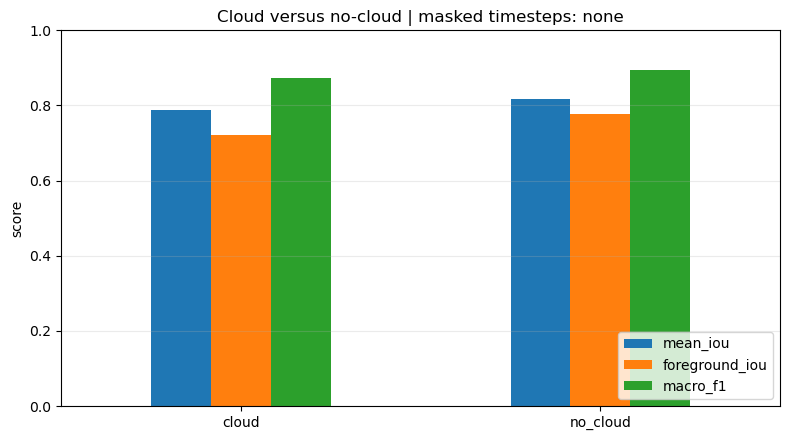

In [9]:
def plot_cloud_comparison(summary, title=None):
    conditions = ["cloud", "no_cloud"]
    selected = (
        summary.set_index("condition")
        .reindex(conditions)
        .reset_index()
    )
    metrics = ["mean_iou", "foreground_iou", "macro_f1"]
    axis = selected.plot(
        x="condition",
        y=metrics,
        kind="bar",
        figsize=(8, 4.5),
        ylim=(0, 1),
        rot=0,
    )
    axis.set_ylabel("score")
    axis.set_xlabel("")
    axis.set_title(title or "Cloud versus no-cloud validation")
    axis.grid(axis="y", alpha=0.25)
    axis.legend(loc="lower right")
    plt.tight_layout()
    plt.show()
    return axis


if evaluation is not None:
    mask_label = evaluation["summary"]["masked_timesteps"].iloc[0]
    plot_cloud_comparison(
        evaluation["summary"],
        title=f"Cloud versus no-cloud | masked timesteps: {mask_label}",
    )


## Optional temporal-masking sweep

Set `RUN_MASKING_SWEEP=True` to evaluate every entry in
`MASKING_SCENARIOS`. Each scenario performs a complete validation pass.
Use `MAX_BATCHES=1` first to verify memory use and table structure.


In [10]:
def evaluate_masking_scenarios(
    model,
    val_datagen,
    scenarios,
    num_classes,
    device,
    **evaluation_kwargs,
):
    summaries = []
    per_class_tables = []
    confusion_matrices = {}

    for scenario, masked_timesteps in scenarios.items():
        print(
            f"\nScenario: {scenario} | masked: "
            f"{masked_timesteps or 'none'}"
        )
        result = calculate_mean_precision_recall(
            model=model,
            val_datagen=val_datagen,
            num_classes=num_classes,
            device=device,
            MASKED_TIMESTEPS=masked_timesteps,
            **evaluation_kwargs,
        )

        summary = result["summary"].copy()
        summary.insert(0, "scenario", scenario)
        summaries.append(summary)

        per_class = result["per_class"].copy()
        per_class.insert(0, "scenario", scenario)
        per_class_tables.append(per_class)

        confusion_matrices[scenario] = result["confusion_matrices"]

    return {
        "summary": pd.concat(summaries, ignore_index=True),
        "per_class": pd.concat(per_class_tables, ignore_index=True),
        "confusion_matrices": confusion_matrices,
    }


In [12]:
RUN_MASKING_SWEEP=True

In [13]:
masking_sweep = None
if RUN_MASKING_SWEEP:
    masking_sweep = evaluate_masking_scenarios(
        model=model,
        val_datagen=val_loader,
        scenarios=MASKING_SCENARIOS,
        num_classes=NUM_CLASSES,
        device=device,
        version_groups=VERSION_GROUPS,
        include_version_rows=INCLUDE_VERSION_ROWS,
        empty_sample_policy=EMPTY_SAMPLE_POLICY,
        max_batches=MAX_BATCHES,
    )

    comparison = masking_sweep["summary"].query(
        "condition in ['cloud', 'no_cloud']"
    )
    display(
        comparison[
            [
                "scenario",
                "condition",
                "masked_timesteps",
                "evaluated_samples",
                "skipped_no_active_frames",
                "mean_iou",
                "foreground_iou",
                "macro_f1",
                "pixel_accuracy",
            ]
        ]
    )
else:
    print("Set RUN_MASKING_SWEEP=True to run all masking scenarios.")



Scenario: all_frames | masked: none
Manual timestep mask: none


Evaluate mask=none: 100%|██████████| 1286/1286 [08:45<00:00,  2.45batch/s]


Completed 1,286 batches in 8.8 minutes.

Scenario: target_only | masked: [1, 2, 4]
Manual timestep mask: t1, t2, t4


Evaluate mask=t1, t2, t4: 100%|██████████| 1286/1286 [08:43<00:00,  2.45batch/s]


Completed 1,286 batches in 8.7 minutes.

Scenario: context_only | masked: [3]
Manual timestep mask: t3


...

Evaluate mask=t3, t4: 100%|██████████| 1286/1286 [08:53<00:00,  2.41batch/s]


Completed 1,286 batches in 8.9 minutes.

Scenario: future_only | masked: [1, 2, 3]
Manual timestep mask: t1, t2, t3


Evaluate mask=t1, t2, t3: 100%|██████████| 1286/1286 [08:56<00:00,  2.40batch/s]

Completed 1,286 batches in 8.9 minutes.


,scenario,condition,masked_timesteps,evaluated_samples,skipped_no_active_frames,mean_iou,foreground_iou,macro_f1,pixel_accuracy
1,all_frames,cloud,none,2572,0,0.787214,0.721346,0.873604,0.993237
2,all_frames,no_cloud,none,2572,0,0.817293,0.776172,0.893961,0.994565
8,target_only,cloud,"1,2,4",2572,0,0.759010,0.689337,0.853027,0.992298
9,target_only,no_cloud,"1,2,4",2572,0,0.801768,0.760348,0.883231,0.994129
15,context_only,cloud,3,2572,0,0.549367,0.361886,0.662440,0.984883
16,context_only,no_cloud,3,2572,0,0.602290,0.437839,0.718746,0.986667
22,history_and_target,cloud,4,2572,0,0.785021,0.720016,0.872017,0.993199
23,history_and_target,no_cloud,4,2572,0,0.815031,0.771268,0.892487,0.994452
29,target_and_future,cloud,"1,2",2572,0,0.762594,0.692604,0.855731,0.992394
30,target_and_future,no_cloud,"1,2",2572,0,0.803890,0.764748,0.884646,0.994234


## Optional CSV export

Results are written only when `SAVE_RESULTS=True`. Existing files with the
same experiment name will be replaced.


## Foreground pixel-count accuracy

These cells compare total predicted small-scale mining pixels against
ground-truth small-scale mining pixels. This is complementary to IoU:
IoU measures spatial overlap, while count error measures whether the
model is estimating the total mapped mining area with low bias.


In [ ]:
BACKGROUND_CLASS_ID = 0
FOREGROUND_CLASS_IDS = [
    class_id
    for class_id in range(NUM_CLASSES)
    if class_id != BACKGROUND_CLASS_ID
]

# Set this if you want the tables to include area units.
# Example: 10 m pixels -> PIXEL_AREA_SQUARE_METERS = 100
PIXEL_AREA_SQUARE_METERS = None


def _count_ratio(numerator, denominator):
    return float(numerator / denominator) if denominator else np.nan


def _pixel_area(pixel_count):
    if PIXEL_AREA_SQUARE_METERS is None:
        return np.nan
    return float(pixel_count * PIXEL_AREA_SQUARE_METERS)


def _foreground_count_row(
    confusion,
    source,
    condition,
    scenario=None,
    class_group="foreground_total",
    class_ids=None,
):
    if class_ids is None:
        class_ids = FOREGROUND_CLASS_IDS

    class_ids = list(class_ids)
    other_ids = [
        class_id
        for class_id in range(confusion.shape[0])
        if class_id not in class_ids
    ]

    true_pixels = int(confusion[class_ids, :].sum())
    predicted_pixels = int(confusion[:, class_ids].sum())
    count_error_pixels = predicted_pixels - true_pixels
    absolute_count_error_pixels = abs(count_error_pixels)

    true_positive_pixels = int(confusion[np.ix_(class_ids, class_ids)].sum())
    false_positive_pixels = int(confusion[np.ix_(other_ids, class_ids)].sum())
    false_negative_pixels = int(confusion[np.ix_(class_ids, other_ids)].sum())

    percent_error = 100 * _count_ratio(count_error_pixels, true_pixels)
    absolute_percent_error = 100 * _count_ratio(
        absolute_count_error_pixels,
        true_pixels,
    )
    predicted_to_true_ratio = _count_ratio(predicted_pixels, true_pixels)
    count_error_fraction = _count_ratio(
        absolute_count_error_pixels,
        true_pixels,
    )
    count_agreement = (
        np.nan
        if np.isnan(count_error_fraction)
        else max(0.0, 1.0 - count_error_fraction)
    )

    return {
        "source": source,
        "scenario": scenario,
        "condition": condition,
        "class_group": class_group,
        "class_ids": ",".join(map(str, class_ids)),
        "true_pixels": true_pixels,
        "predicted_pixels": predicted_pixels,
        "count_error_pixels": count_error_pixels,
        "absolute_count_error_pixels": absolute_count_error_pixels,
        "percent_error": percent_error,
        "absolute_percent_error": absolute_percent_error,
        "predicted_to_true_ratio": predicted_to_true_ratio,
        "count_agreement": count_agreement,
        "true_positive_pixels": true_positive_pixels,
        "false_positive_pixels": false_positive_pixels,
        "false_negative_pixels": false_negative_pixels,
        "true_area_square_meters": _pixel_area(true_pixels),
        "predicted_area_square_meters": _pixel_area(predicted_pixels),
        "area_error_square_meters": _pixel_area(count_error_pixels),
    }


def foreground_pixel_count_stats_from_confusion_matrices(
    confusion_matrices,
    source,
    scenario=None,
):
    rows = []
    for condition, confusion in confusion_matrices.items():
        confusion = np.asarray(confusion)
        rows.append(
            _foreground_count_row(
                confusion=confusion,
                source=source,
                scenario=scenario,
                condition=condition,
                class_group="foreground_total",
                class_ids=FOREGROUND_CLASS_IDS,
            )
        )

        for class_id in FOREGROUND_CLASS_IDS:
            rows.append(
                _foreground_count_row(
                    confusion=confusion,
                    source=source,
                    scenario=scenario,
                    condition=condition,
                    class_group=CLASS_NAMES.get(
                        class_id,
                        f"class_{class_id}",
                    ),
                    class_ids=[class_id],
                )
            )

    return pd.DataFrame(rows)


def build_foreground_pixel_count_stats(
    evaluation=None,
    masking_sweep=None,
):
    tables = []
    if evaluation is not None:
        tables.append(
            foreground_pixel_count_stats_from_confusion_matrices(
                evaluation["confusion_matrices"],
                source="single_evaluation",
            )
        )

    if masking_sweep is not None:
        for scenario, matrices in masking_sweep[
            "confusion_matrices"
        ].items():
            tables.append(
                foreground_pixel_count_stats_from_confusion_matrices(
                    matrices,
                    source="masking_sweep",
                    scenario=scenario,
                )
            )

    if not tables:
        return pd.DataFrame()

    return pd.concat(tables, ignore_index=True)


In [ ]:
pixel_count_stats = build_foreground_pixel_count_stats(
    evaluation=evaluation,
    masking_sweep=masking_sweep,
)

count_columns = [
    "source",
    "scenario",
    "condition",
    "class_group",
    "true_pixels",
    "predicted_pixels",
    "count_error_pixels",
    "percent_error",
    "absolute_percent_error",
    "predicted_to_true_ratio",
    "count_agreement",
]

if pixel_count_stats.empty:
    print(
        "Run the single evaluation or masking sweep first to compute "
        "foreground pixel-count statistics."
    )
else:
    foreground_total_counts = pixel_count_stats.query(
        "class_group == 'foreground_total'"
    )

    display(
        foreground_total_counts[
            foreground_total_counts["condition"].isin(
                ["all", "cloud", "no_cloud"]
            )
        ][count_columns]
    )

    display(
        pixel_count_stats[
            pixel_count_stats["condition"].isin(
                ["all", "cloud", "no_cloud"]
            )
        ][count_columns]
    )


In [ ]:
if SAVE_RESULTS and not pixel_count_stats.empty:
    RESULTS_DIRECTORY.mkdir(parents=True, exist_ok=True)
    pixel_count_stats.to_csv(
        RESULTS_DIRECTORY / "foreground_pixel_count_stats.csv",
        index=False,
    )
    print(
        "Saved foreground pixel-count statistics to "
        f"{(RESULTS_DIRECTORY / 'foreground_pixel_count_stats.csv').resolve()}"
    )
else:
    print(
        "Foreground pixel-count CSV not saved. "
        "Set SAVE_RESULTS=True and run this cell to write it."
    )


In [ ]:
if SAVE_RESULTS:
    RESULTS_DIRECTORY.mkdir(parents=True, exist_ok=True)

    if evaluation is not None:
        mask_label = (
            "-".join(map(str, evaluation["masked_timesteps"]))
            if evaluation["masked_timesteps"]
            else "none"
        )
        evaluation["summary"].to_csv(
            RESULTS_DIRECTORY / f"summary_mask-{mask_label}.csv",
            index=False,
        )
        evaluation["per_class"].to_csv(
            RESULTS_DIRECTORY / f"per_class_mask-{mask_label}.csv",
            index=False,
        )

    if masking_sweep is not None:
        masking_sweep["summary"].to_csv(
            RESULTS_DIRECTORY / "masking_sweep_summary.csv",
            index=False,
        )
        masking_sweep["per_class"].to_csv(
            RESULTS_DIRECTORY / "masking_sweep_per_class.csv",
            index=False,
        )

    print(f"Saved evaluation tables under {RESULTS_DIRECTORY.resolve()}")
else:
    print("SAVE_RESULTS=False; no CSV files written.")


## Interpretation notes

- `cloud` combines `harmonized_cloudy` and `sr_harmonized_cloudy`.
- `no_cloud` combines `harmonized` and `sr_harmonized`.
- Exact-version rows expose differences hidden by the two broad groups.
- `mean_iou` is a macro average over classes present in the condition.
- `foreground_iou` merges all non-background classes and is usually the
  clearest footprint metric.
- Compare `evaluated_samples` and `skipped_no_active_frames` before comparing
  masking scenarios, especially history-only or future-only experiments.
- Attention maps are descriptive; metric changes under controlled masking
  provide stronger evidence that a timestep contributes to segmentation.
